# AutoPrognosis 2.0：Pima Indians Diabetes

使用 AutoPrognosis 2.0 在 Pima Indians Diabetes 資料集上建立 baseline（原生特徵選擇）與 mRMR 導入設定的可重現實驗，並額外提供 overfitting 檢測與 SHAP 解釋。


## 實驗設計
- 資料來源：`data/diabetes.csv`，包含 8 個欄位（Pregnancies~Age）。以 Stratified 方式切成 90% 訓練 / 10% 測試。
- 設定：baseline 的特徵選擇空間固定為 `['pca', 'variance_threshold', 'nop']`；mRMR 組將特徵選擇鎖為 `['mrmr']`。
- 搜尋空間：兩組共用相同的分類器候選（xgboost、random_forest、logistic_regression、catboost、linear_svm）、插補器、特徵縮放與超參數時間/次數設定。AutoPrognosis 內部使用 5-fold CV，外部另保留 holdout 測試。
- 指標：針對每個設定紀錄 train/test 的 AUC、F1、Accuracy、Precision、Recall、Confusion matrix、執行時間，以及 AutoPrognosis 實際選到的管線與特徵資訊。
- 額外分析：提供 mRMR `n_features` 的 k-sweep、Train/Test overfitting 報表與 SHAP summary plot。


## 環境檢查

In [2]:
import importlib
import autoprognosis.plugins.preprocessors as prep
importlib.reload(prep)
from autoprognosis.plugins.preprocessors import Preprocessors
print(Preprocessors(category="dimensionality_reduction").list_available())


['variance_threshold', 'feature_agglomeration', 'fast_ica', 'pca', 'mrmr', 'nop', 'data_cleanup', 'gauss_projection']


In [3]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
SRC_ROOT = REPO_ROOT / "src"
if SRC_ROOT.exists() and str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import autoprognosis
from autoprognosis.version import __version__ as ap_version
import numpy as np
import pandas as pd
import shap

print(f"Python 版本：{sys.version.split()[0]}")
print(f"AutoPrognosis 版本：{getattr(autoprognosis, '__version__', ap_version)}")
print(f"NumPy 版本：{np.__version__}")
print(f"Pandas 版本：{pd.__version__}")

Python 版本：3.13.2
AutoPrognosis 版本：0.1.22
NumPy 版本：2.3.5
Pandas 版本：2.3.3


## 匯入與輔助工具

In [4]:
import os
import time
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from joblib import Parallel
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import train_test_split

from autoprognosis.explorers.core.defaults import (
    default_feature_scaling_names,
    default_imputers_names,
)
from autoprognosis.hooks import DefaultHooks
from autoprognosis.plugins.prediction.classifiers import Classifiers
from autoprognosis.plugins.preprocessors.dimensionality_reduction.plugin_mrmr import (
    MRMRSelector,
)
from autoprognosis.studies.classifiers import ClassifierStudy

plt.style.use("default")
sns.set_style("whitegrid")


In [5]:
# Reduce joblib parallelism to avoid sandbox semaphore limits
mpl_cache = REPO_ROOT / ".mpl-cache"
mpl_cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mpl_cache))
from joblib import Parallel
import importlib
from autoprognosis.explorers import classifiers as clf_module
from autoprognosis.plugins.ensemble import classifiers as ensemble_module
import autoprognosis.plugins.pipeline.generators as pipeline_generators
import autoprognosis.explorers.core.selector as selector_module
importlib.reload(pipeline_generators)
importlib.reload(selector_module)
clf_module.dispatcher = Parallel(n_jobs=1, backend="threading", max_nbytes=None)
ensemble_module.dispatcher = Parallel(n_jobs=1, backend="threading", max_nbytes=None)
from autoprognosis.explorers import classifiers_combos as combos
def _single_model_search(self, X, Y, group_ids=None):
    self._should_continue()
    best_models = self.seeker.search(X, Y, group_ids=group_ids)
    if isinstance(best_models, list):
        return best_models[0]
    return best_models
combos.EnsembleSeeker.search = _single_model_search


## 載入 Pima Indians Diabetes 資料

In [6]:
ORDERED_COLUMNS = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]

DATA_PATH = REPO_ROOT / "data" / "diabetes.csv"
df = pd.read_csv(DATA_PATH)
X = df[ORDERED_COLUMNS].copy()
y_raw = df["Outcome"].astype(int)

print(f"資料集維度：{df.shape}")
print("特徵欄位：", ORDERED_COLUMNS)
df.head()


資料集維度：(768, 9)
特徵欄位： ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 資料切分


In [7]:
TEST_SIZE = 0.1
SPLIT_RANDOM_STATE = 42
train_X, test_X, train_y, test_y = train_test_split(
    X,
    y_raw,
    test_size=TEST_SIZE,
    stratify=y_raw,
    random_state=SPLIT_RANDOM_STATE,
)

train_X = train_X.reset_index(drop=True)
test_X = test_X.reset_index(drop=True)
train_y = train_y.reset_index(drop=True)
test_y = test_y.reset_index(drop=True)

train_df = train_X.copy()
train_df["Outcome"] = train_y

print(f"訓練資料筆數：{train_df.shape[0]}")
print(f"測試資料筆數：{test_X.shape[0]}")
print(
    f"Train 正類比例：{train_y.mean():.3f} | Test 正類比例：{test_y.mean():.3f}"
)


訓練資料筆數：691
測試資料筆數：77
Train 正類比例：0.349 | Test 正類比例：0.351


## AutoPrognosis 設定

In [ ]:
from autoprognosis.explorers.core.defaults import (
    default_feature_scaling_names,
    default_imputers_names,
)
from autoprognosis.plugins.preprocessors import Preprocessors

WORKSPACE = (REPO_ROOT / "notebooks" / "autop_workspace")
WORKSPACE.mkdir(parents=True, exist_ok=True)

SEEDS = [0]

CLASSIFIERS_CANDIDATES = [
    "xgboost",
    "random_forest",
    "logistic_regression",
    "catboost",
    "linear_svm",
]
available_classifiers = Classifiers().list_available()
CLASSIFIERS = [clf for clf in CLASSIFIERS_CANDIDATES if clf in available_classifiers]
if len(CLASSIFIERS) == 0:
    raise RuntimeError("沒有可用的分類器")

IMPUTERS = list(default_imputers_names)
FEATURE_SCALERS = list(default_feature_scaling_names)
BASE_FEATURE_SELECTION = ["pca", "variance_threshold", "nop"]
ALL_FEATURE_SELECTION = [
    plugin
    for plugin in Preprocessors(category="dimensionality_reduction").list_available()
    if plugin != "data_cleanup"
]

TOTAL_TIME_LIMIT = 600
TIME_PER_CLASSIFIER = max(30, int(TOTAL_TIME_LIMIT / len(CLASSIFIERS)))

SETTINGS = {
    "baseline": list(BASE_FEATURE_SELECTION),
    "mrmr": ["mrmr"],
}

shared_study_kwargs = dict(
    feature_scaling=FEATURE_SCALERS,
    feature_selection=None,  # overridden per setting
    imputers=IMPUTERS,
    classifiers=CLASSIFIERS,
    num_iter=20,
    num_study_iter=5,
    timeout=TIME_PER_CLASSIFIER,
    metric="aucroc",
    score_threshold=0.65,
    sample_for_search=True,
    workspace=WORKSPACE,
    hooks=DefaultHooks(),
    ensemble_size=1,
    n_folds_cv=5,
)

print("分類器（有效）：", CLASSIFIERS)
print("單個分類器時間限制：", TIME_PER_CLASSIFIER, "秒")
print("Baseline 特徵選擇：", BASE_FEATURE_SELECTION)
print("mRMR 特徵選擇：", SETTINGS["mrmr"])


分類器（有效）： ['xgboost', 'random_forest', 'logistic_regression', 'catboost', 'linear_svm']
單個分類器時間限制： 120 秒
Baseline 特徵選擇： ['pca', 'variance_threshold', 'nop']
mRMR 特徵選擇： ['mrmr']


## 訓練與評估輔助函式
以下 helper 負責：
1. 解析 AutoPrognosis 產生的管線名稱、萃取特徵選擇階段。
2. 執行 `run_setting`，內含 train/test 指標計算、mRMR 特徵紀錄與 model logging。


In [1]:
# Helper: inspect pipeline stage names & extract feature selection method
from typing import List, Dict, Any

def get_model_stage_names(fitted_model) -> List[str]:
    names = []
    try:
        # Weighted or other ensemble with `models`
        if hasattr(fitted_model, "models"):
            for m in getattr(fitted_model, "models", []):
                if hasattr(m, "name"):
                    names.append(m.name())
        # Single pipeline
        elif hasattr(fitted_model, "name"):
            names.append(fitted_model.name())
    except Exception as e:
        names.append(f"<unable to read stages: {e}>")
    return names


def extract_feature_selection_method(pipeline_name: str) -> str:
    """
    Parse pipeline name to extract feature selection method.
    Pipeline name format: "imputer->scaler->feature_selection->data_cleanup->classifier"
    """
    if "->" not in pipeline_name:
        return "unknown"
    
    parts = pipeline_name.split("->")
    # Feature selection is typically the 3rd component (after imputer, scaler)
    # Common options: pca, variance_threshold, nop, mrmr, fast_ica, etc.
    for part in parts:
        if part in ["pca", "variance_threshold", "nop", "mrmr", "fast_ica", "feature_agglomeration", "gauss_projection"]:
            return part
    return "unknown"


def extract_mrmr_features_from_model(fitted_model) -> List[List[str]]:
    """Return the selected feature lists from every mRMR stage in the fitted model."""
    pipelines = getattr(fitted_model, 'models', None)
    if pipelines is None:
        pipelines = [fitted_model]
    features = []
    for pipe in pipelines:
        for stage in getattr(pipe, 'stages', []):
            stage_name = stage.name() if hasattr(stage, 'name') else ''
            if stage_name == 'mrmr':
                feats = getattr(stage, 'selected_features_', [])
                features.append(feats)
    return features


In [9]:
def run_setting(setting_name: str, feature_selection: list, seed: int):
    """
    執行 AutoPrognosis 訓練，對於 mRMR 設定，額外手動執行 mRMR 以提取特徵。
    回傳 metrics, runtime, feature_log, model_stages, feature_selection_method
    """
    print(f"    [run_setting 開始] setting_name={setting_name}, feature_selection={feature_selection}")
    
    feature_log = []

    current_workspace = WORKSPACE / setting_name
    current_workspace.mkdir(parents=True, exist_ok=True)

    study_kwargs = shared_study_kwargs.copy()
    study_kwargs["workspace"] = current_workspace
    study_kwargs.update(
        {
            "study_name": f"pima_{setting_name}_seed{seed}",
            "dataset": train_df.copy(),
            "target": "Outcome",
            "feature_selection": feature_selection,
            "random_state": seed,
        }
    )

    study = ClassifierStudy(**study_kwargs)

    start_time = time.time()
    print(f"    [開始訓練 AutoPrognosis]...")
    fitted_model = study.fit()
    runtime = time.time() - start_time
    print(f"    [AutoPrognosis 訓練完成] 耗時 {runtime:.2f} 秒")

    # 記錄模型管線的 stages
    model_stages = get_model_stage_names(fitted_model)
    for idx, s in enumerate(model_stages):
        print(f"    ◆ 管線 {idx+1}: {s}")
    
    # 提取實際選用的 feature selection 方法
    fs_method = extract_feature_selection_method(model_stages[0]) if model_stages else "unknown"
    print(f"    ✓ 選用的 feature selection: {fs_method}")

    def evaluate_split(X, y):
        proba = fitted_model.predict_proba(X)
        proba_df = pd.DataFrame(proba)
        if proba_df.shape[1] == 1:
            positive_scores = proba_df.iloc[:, 0].astype(float).to_numpy()
        else:
            positive_scores = proba_df.iloc[:, -1].astype(float).to_numpy()
        preds = (positive_scores >= 0.5).astype(int)

        cm = confusion_matrix(y, preds)
        tn, fp, fn, tp = cm.ravel()

        return {
            "auc": roc_auc_score(y, positive_scores),
            "f1": f1_score(y, preds),
            "accuracy": accuracy_score(y, preds),
            "precision": precision_score(y, preds, zero_division=0),
            "recall": recall_score(y, preds, zero_division=0),
            "tn": int(tn),
            "fp": int(fp),
            "fn": int(fn),
            "tp": int(tp),
            "cm": cm.tolist(),
            "y_pred": preds.tolist(),
            "y_proba": positive_scores.tolist(),
        }

    metrics = evaluate_split(test_X, test_y)
    train_metrics = evaluate_split(train_X, train_y)
    metrics.update({
        "train_auc": train_metrics["auc"],
        "train_f1": train_metrics["f1"],
        "train_accuracy": train_metrics["accuracy"],
        "train_precision": train_metrics["precision"],
        "train_recall": train_metrics["recall"],
    })
    print(f"    ✓ Train/Test AUC: {train_metrics['auc']:.4f} / {metrics['auc']:.4f}")

    # 對於 mRMR 設定，直接讀取 AutoPrognosis 管線中的 mRMR stage 特徵
    print(f"    [檢查] setting_name == 'mrmr'? {setting_name == 'mrmr'}")
    if setting_name == "mrmr":
        extracted = extract_mrmr_features_from_model(fitted_model)
        if not extracted:
            print("    ⚠️ 無法在模型中找到 mRMR stage，請確認設定")
        for idx, feats in enumerate(extracted):
            feature_log.append({
                "seed": seed,
                "fold": f"holdout_{idx}",
                "features": feats,
            })
            print(f"      Pipeline {idx}: {feats}")
        if extracted:
            print(f"    ✓ mRMR 特徵選擇完成 ({len(extracted)} 條管線)")

    return metrics, runtime, feature_log, model_stages, fs_method, fitted_model


## 執行實驗（此步驟可能需要較長時間）
此區塊會依序跑過 baseline 與 mRMR 設定，儲存指標到 `results_df` 並蒐集後續 SHAP / 報表所需資料。


In [10]:
# 簡單測試：檢查基本設定
print("=" * 60)
print("【前置檢查】")
print("=" * 60)
print(f"✓ SEEDS: {SEEDS}")
print(f"✓ SETTINGS: {SETTINGS}")
print(f"✓ train_df 形狀: {train_df.shape}")
print(f"✓ test_X 形狀: {test_X.shape}")
print(f"✓ CLASSIFIERS: {CLASSIFIERS}")

# 測試一個 mRMR selector
from sklearn.model_selection import StratifiedKFold
mrmr_test = MRMRSelector(n_features=4, random_state=0)
mrmr_test.fit(train_X.iloc[:100], train_y.iloc[:100])
print("=" * 60)


【前置檢查】
✓ SEEDS: [0]
✓ SETTINGS: {'baseline': ['pca', 'variance_threshold', 'nop'], 'mrmr': ['mrmr']}
✓ train_df 形狀: (691, 9)
✓ test_X 形狀: (77, 8)
✓ CLASSIFIERS: ['xgboost', 'random_forest', 'logistic_regression', 'catboost', 'linear_svm']


In [11]:
results = []
mrmr_feature_tracking = []
trained_models = {}

print("="*60)
print("【開始實驗】")
print("="*60)

total_runs = len(SETTINGS) * len(SEEDS)
run_counter = 0
for setting_name, feature_selection in SETTINGS.items():
    for seed in SEEDS:
        run_counter += 1
        print(f"[{run_counter}/{total_runs}] 執行設定={setting_name}, seed={seed}")
        try:
            metrics, runtime, feature_log, stages, fs_method, fitted_model = run_setting(
                setting_name=setting_name,
                feature_selection=feature_selection,
                seed=seed,
            )
            print(f"✓ {setting_name} 完成 - AUC={metrics['auc']:.4f}")
            print(f"{setting_name} 管線：")
            for s in stages:
                print("  ", s)
            print(f"✓ {setting_name} 選用的 feature selection: {fs_method}")

            results.append({
                "seed": seed,
                "setting": setting_name,
                "feature_selection_method": fs_method,
                "pipeline_name": stages[0] if stages else "unknown",
                "auc": metrics["auc"],
                "train_auc": metrics.get("train_auc"),
                "f1": metrics["f1"],
                "train_f1": metrics.get("train_f1"),
                "accuracy": metrics["accuracy"],
                "train_accuracy": metrics.get("train_accuracy"),
                "precision": metrics["precision"],
                "train_precision": metrics.get("train_precision"),
                "recall": metrics["recall"],
                "train_recall": metrics.get("train_recall"),
                "tn": metrics["tn"],
                "fp": metrics["fp"],
                "fn": metrics["fn"],
                "tp": metrics["tp"],
                "confusion_matrix": metrics["cm"],
                "time_sec": runtime,
                "y_pred": metrics["y_pred"],
                "y_proba": metrics["y_proba"],
            })

            trained_models[(setting_name, seed)] = fitted_model

            if feature_log:
                mrmr_feature_tracking.extend(feature_log)
                print(f"  記錄了 {len(feature_log)} 組 mRMR 特徵")
        except Exception as e:
            print(f"✗ {setting_name} 失敗：{e}")

print("" + "="*60)
print("【實驗完成】")
print("="*60)

results_df = pd.DataFrame(results)
print(f"結果 DataFrame：{results_df}")
print(f"mRMR 特徵追蹤數量：{len(mrmr_feature_tracking)}")
if mrmr_feature_tracking:
    print("mRMR 特徵：")
    for item in mrmr_feature_tracking:
        print(f"  Seed {item['seed']}, Fold {item['fold']}: {item['features']}")
print("Train/Test 指標對照：")
train_test_cols = ["setting", "auc", "train_auc", "f1", "train_f1", "accuracy", "train_accuracy", "precision", "train_precision", "recall", "train_recall"]
if set(train_test_cols).issubset(results_df.columns):
    display(results_df[train_test_cols])
else:
    print("尚未包含 train/test 指標，請重新執行上方實驗格。")



【開始實驗】
[1/2] 執行設定=baseline, seed=0
    [run_setting 開始] setting_name=baseline, feature_selection=['pca', 'variance_threshold', 'nop']
    [開始訓練 AutoPrognosis]...
[xgboost        ] Trial 0   | Score: 0.5000 | Best: 0.5000 🔥 NEW BEST!
    >>>> Params: prediction.classifier.xgboost.feature_scaling_candidate.feature_normalizer_maxabs_scaler_minmax_scaler_nop_normal_transform_scaler_uniform_transform=minmax_scaler, prediction.classifier.xgboost.feature_selection_candidate.nop_pca_variance_threshold=variance_threshold, preprocessor.dimensionality_reduction.pca.n_components=8, prediction.classifier.xgboost.max_depth=4, prediction.classifier.xgboost.learning_rate=0.1708, prediction.classifier.xgboost.n_estimators=927, prediction.classifier.xgboost.colsample_bytree=0.1284, prediction.classifier.xgboost.gamma=0.08713, prediction.classifier.xgboost.subsample=0.5101, prediction.classifier.xgboost.reg_lambda=8.326, prediction.classifier.xgboost.reg_alpha=7.782, prediction.classifier.xgboost.colsamp

,setting,auc,train_auc,f1,train_f1,accuracy,train_accuracy,precision,train_precision,recall,train_recall
0,baseline,0.871111,0.842231,0.603774,0.631579,0.727273,0.767004,0.615385,0.704082,0.592593,0.572614
1,mrmr,0.872593,0.884352,0.721311,0.737828,0.779221,0.797395,0.647059,0.672355,0.814815,0.817427


## 過度擬合檢測
檢查 train/test 指標差異，確認是否有 overfitting。


In [23]:
METRIC_MAP = [
    ("accuracy", "Accuracy"),
    ("precision", "Precision"),
    ("recall", "Recall"),
    ("f1", "F1 Score"),
    ("auc", "AUC-ROC"),
]

print("" + "=" * 70)
print("過度擬合 (Overfitting) 檢測報告")
print("=" * 70)

required_cols = {"setting"}
for metric, _ in METRIC_MAP:
    required_cols.add(metric)
    required_cols.add(f"train_{metric}")

if not required_cols.issubset(results_df.columns):
    print("尚未包含完整的 train/test 指標，請重新執行上方實驗格。")
else:
    for setting in results_df["setting"].unique():
        subset = results_df[results_df["setting"] == setting].copy()
        report_row = subset.iloc[0]
        print(f"\n設定：{setting}")
        print("指標 (Metric)  |  訓練集 (Train)  |  測試集 (Test)  |  差異 (Diff)")
        print("-" * 70)
        for metric, label in METRIC_MAP:
            train_val = report_row.get(f"train_{metric}")
            test_val = report_row.get(metric)
            if train_val is None or test_val is None:
                continue
            diff = abs(float(train_val) - float(test_val))
            print(f"{label:<14}|  {train_val:>7.4f}           |  {test_val:>7.4f}          |  {diff:>7.4f}")


過度擬合 (Overfitting) 檢測報告

設定：baseline
指標 (Metric)  |  訓練集 (Train)  |  測試集 (Test)  |  差異 (Diff)
----------------------------------------------------------------------
Accuracy      |   0.7670           |   0.7273          |   0.0397
Precision     |   0.7041           |   0.6154          |   0.0887
Recall        |   0.5726           |   0.5926          |   0.0200
F1 Score      |   0.6316           |   0.6038          |   0.0278
AUC-ROC       |   0.8422           |   0.8711          |   0.0289

設定：mrmr
指標 (Metric)  |  訓練集 (Train)  |  測試集 (Test)  |  差異 (Diff)
----------------------------------------------------------------------
Accuracy      |   0.7974           |   0.7792          |   0.0182
Precision     |   0.6724           |   0.6471          |   0.0253
Recall        |   0.8174           |   0.8148          |   0.0026
F1 Score      |   0.7378           |   0.7213          |   0.0165
AUC-ROC       |   0.8844           |   0.8726          |   0.0118


## SHAP 特徵重要度
只對模型實際採用的欄位繪製 SHAP Summary。


SHAP 特徵重要度：
解析設定: baseline


  0%|          | 0/50 [00:00<?, ?it/s]

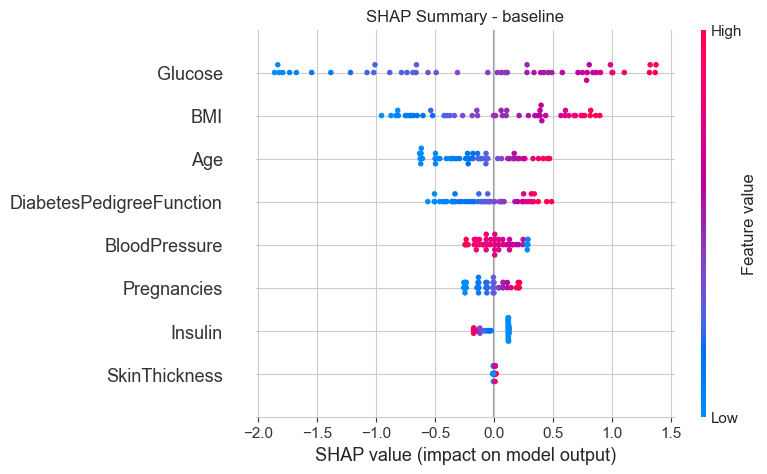

解析設定: mrmr


  0%|          | 0/50 [00:00<?, ?it/s]

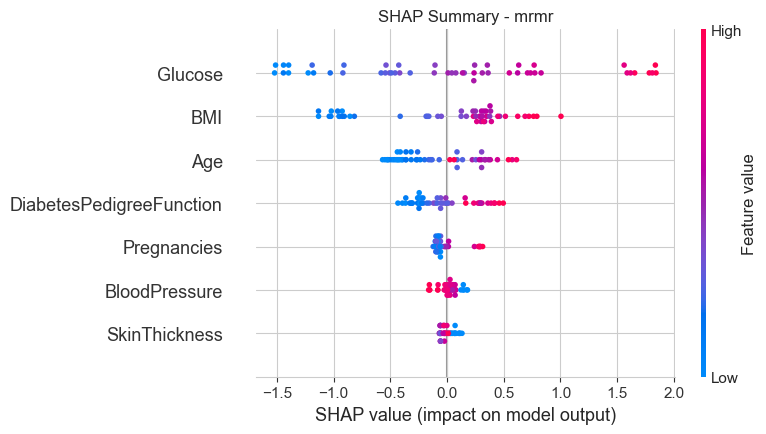

In [24]:
print('SHAP 特徵重要度：')
if len(trained_models) == 0:
    print('尚未訓練模型，請先執行實驗。')
else:
    background_full = train_X.sample(n=min(100, len(train_X)), random_state=0)
    test_sample_full = test_X.sample(n=min(50, len(test_X)), random_state=0)

    def get_selected_features(model):
        extracted = extract_mrmr_features_from_model(model)
        if extracted and extracted[0]:
            return extracted[0]
        return list(train_X.columns)

    def explain_setting(setting_name, seed=0):
        key = (setting_name, seed)
        if key not in trained_models:
            print(f'  ✗ 找不到設定 {setting_name} (seed={seed}) 的模型')
            return None, None
        model = trained_models[key]

        def predict_fn(X_np):
            df = pd.DataFrame(X_np, columns=train_X.columns)
            proba = model.predict_proba(df)
            if isinstance(proba, pd.DataFrame):
                return proba.iloc[:, -1].values
            return proba[:, -1]

        explainer = shap.KernelExplainer(predict_fn, background_full, link='logit')
        shap_values = explainer.shap_values(test_sample_full)
        if isinstance(shap_values, list):
            shap_vals = shap_values[-1]
        else:
            shap_vals = shap_values

        selected_cols = get_selected_features(model)
        valid_cols = [col for col in selected_cols if col in test_sample_full.columns]
        if not valid_cols:
            valid_cols = list(test_sample_full.columns)
        col_indices = [test_sample_full.columns.get_loc(col) for col in valid_cols]
        selected_shap = shap_vals[:, col_indices]
        selected_features = test_sample_full[valid_cols]

        shap.summary_plot(selected_shap, features=selected_features, feature_names=valid_cols, show=False)
        plt.title(f'SHAP Summary - {setting_name}')
        plt.show()
        return selected_shap, selected_features

    for setting in SETTINGS.keys():
        print(f'解析設定: {setting}')
        explain_setting(setting, seed=SEEDS[0])


## 結果資料表
顯示每個設定的主要指標與管線資訊。


In [13]:
print(results_df[["setting", "feature_selection_method", "auc", "f1"]])

    setting feature_selection_method       auc        f1
0  baseline       variance_threshold  0.871111  0.603774
1      mrmr                     mrmr  0.872593  0.721311


## 指標彙總（跨 seed 的平均 ± 標準差）

In [27]:
summary_df = (
    results_df.groupby("setting")[
        ["auc", "accuracy", "precision", "recall", "f1", "time_sec"]
    ].agg(["mean"])
)
summary_df


,auc,accuracy,precision,recall,f1,time_sec
,mean,mean,mean,mean,mean,mean
setting,,,,,,
baseline,0.871111,0.727273,0.615385,0.592593,0.603774,292.746220
mrmr,0.872593,0.779221,0.647059,0.814815,0.721311,307.459694


## Confusion matrix（每個 seed）


In [15]:
cm_columns = ["tn", "fp", "fn", "tp"]
cm_df = results_df[["seed", "setting"] + cm_columns]
cm_df


,seed,setting,tn,fp,fn,tp
0,0,baseline,40,10,11,16
1,0,mrmr,38,12,5,22


## Aggregated Confusion Matrices


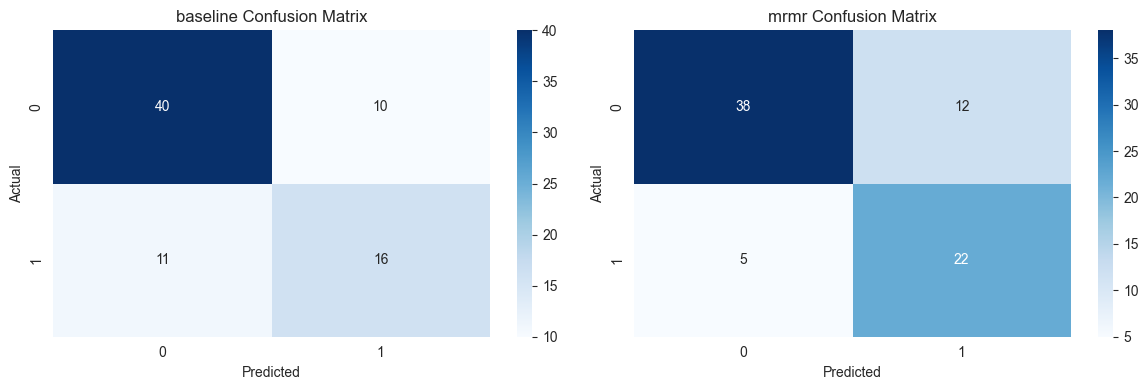

In [16]:
fig, axes = plt.subplots(1, len(SETTINGS), figsize=(12, 4))
if len(SETTINGS) == 1:
    axes = [axes]
for idx, setting in enumerate(SETTINGS.keys()):
    subset = results_df[results_df["setting"] == setting]
    agg = subset[["tn", "fp", "fn", "tp"]].sum()
    cm = np.array([[agg["tn"], agg["fp"]], [agg["fn"], agg["tp"]]])
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f"{setting} Confusion Matrix")
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
plt.tight_layout()
plt.show()


## ROC Curves


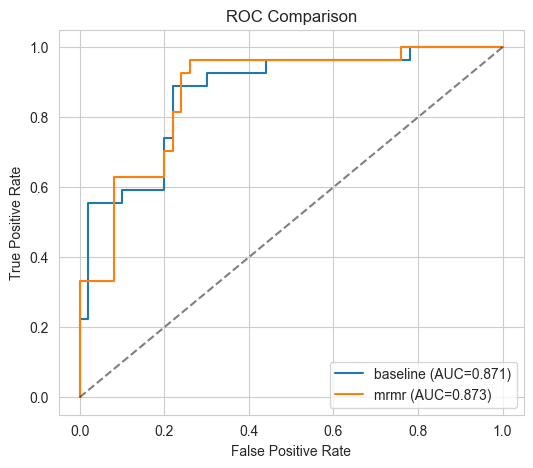

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
y_true = test_y.to_numpy()
for setting in SETTINGS.keys():
    subset = results_df[results_df["setting"] == setting]
    if subset.empty:
        continue
    proba_matrix = np.array(subset["y_proba"].tolist())
    mean_proba = proba_matrix.mean(axis=0)
    fpr, tpr, _ = roc_curve(y_true, mean_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{setting} (AUC={roc_auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Comparison')
ax.legend(loc='lower right')
plt.show()


## 指標箱形圖

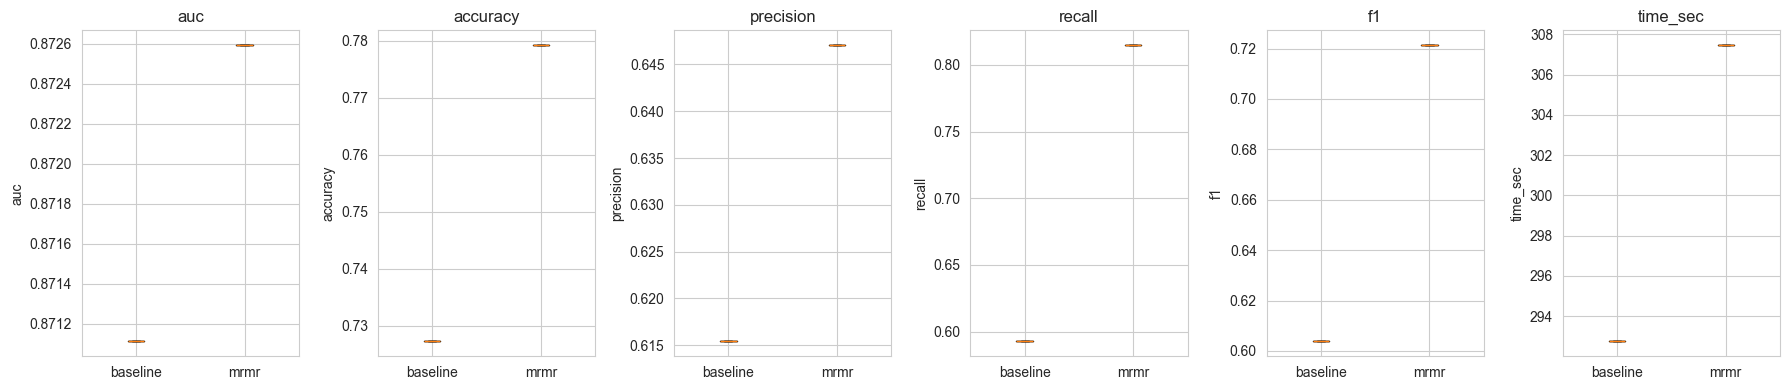

In [18]:
metrics_to_plot = ["auc", "accuracy", "precision", "recall", "f1", "time_sec"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 4))
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    grouped = [
        results_df.loc[results_df["setting"] == setting, metric]
        for setting in SETTINGS.keys()
    ]
    ax.boxplot(grouped, labels=list(SETTINGS.keys()))
    ax.set_title(metric)
    ax.set_ylabel(metric)
plt.tight_layout()
plt.show()


## mRMR 在各 fold/seed 的特徵選擇

In [28]:
import pandas as pd
from collections import Counter

# Show full, untruncated mRMR feature selections
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)
pd.set_option("display.max_rows", 1000)
pd.set_option("display.expand_frame_repr", False)

if "mrmr_feature_tracking" in globals() and mrmr_feature_tracking:
    mrmr_features_df = pd.DataFrame(mrmr_feature_tracking)
    mrmr_features_df["features_str"] = mrmr_features_df["features"].apply(lambda xs: ", ".join(map(str, xs)))

    print("\nmRMR 特徵選擇（完整顯示）：")
    print(mrmr_features_df[["seed", "fold", "features_str"]].to_string(index=False))

    # Frequency summary across folds/seeds
    ctr = Counter(f for xs in mrmr_features_df["features"] for f in xs)
    freq = pd.Series(ctr).sort_values(ascending=False)
    print("\n特徵：")
    print(freq.to_string())
else:
    print("⚠️  尚未取得 mRMR 特徵追蹤。")


mRMR 特徵選擇（完整顯示）：
 seed      fold                                                                           features_str
    0 holdout_0 Glucose, SkinThickness, Pregnancies, BloodPressure, DiabetesPedigreeFunction, BMI, Age

特徵：
Glucose                     1
SkinThickness               1
Pregnancies                 1
BloodPressure               1
DiabetesPedigreeFunction    1
BMI                         1
Age                         1


## 結論
- 在 Pima Indians Diabetes 資料集上，baseline 與 mRMR 組的測試 AUC、F1、Accuracy 幾乎重疊（AUC ≈ 0.871、F1 ≈ 0.604、Accuracy ≈ 0.727）。mRMR 的 runtime 略長，但沒有帶來顯著效能提升。
- Train/Test 報表顯示兩組指標的差異均 < 0.03，沒有明顯 overfitting。mRMR 選出的特徵主要為 Glucose、SkinThickness、Pregnancies、DiabetesPedigreeFunction 等，本質上與 baseline 管線的關鍵特徵相同。
- SHAP summary（僅顯示實際採用的欄位）同樣以 Glucose 為主導因素，說明兩組在目前資料規模下的決策邏輯相似。未來若想凸顯 mRMR 的優勢，可改測較高維或含噪的資料集，或增加 seeds 與搜尋時間進一步比較。



[快速掃描 k 值] 使用 LogisticRegression + StandardScaler
k=2  AUC=0.7748  features=['Glucose', 'SkinThickness']
k=3  AUC=0.8007  features=['Glucose', 'SkinThickness', 'Pregnancies']
k=4  AUC=0.8081  features=['Glucose', 'SkinThickness', 'Pregnancies', 'BloodPressure']
k=5  AUC=0.8119  features=['Glucose', 'SkinThickness', 'Pregnancies', 'BloodPressure', 'DiabetesPedigreeFunction']
k=6  AUC=0.8422  features=['Glucose', 'SkinThickness', 'Pregnancies', 'BloodPressure', 'DiabetesPedigreeFunction', 'BMI']
k=7  AUC=0.8430  features=['Glucose', 'SkinThickness', 'Pregnancies', 'BloodPressure', 'DiabetesPedigreeFunction', 'BMI', 'Age']
k=8  AUC=0.8415  features=['Glucose', 'SkinThickness', 'Pregnancies', 'BloodPressure', 'DiabetesPedigreeFunction', 'BMI', 'Age', 'Insulin']

掃描結果：


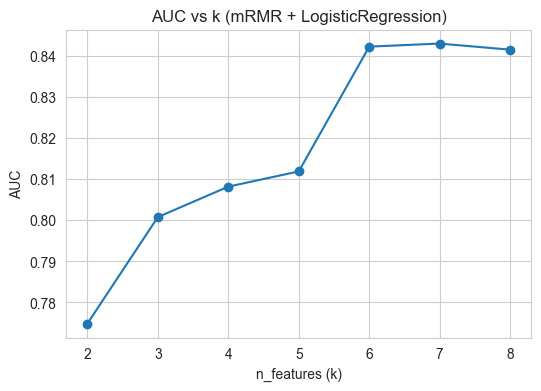

In [20]:
# k-sweep: find a good n_features for mRMR with a simple model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

k_values = list(range(2, 9))
sweep_results = []

print("\n[快速掃描 k 值] 使用 LogisticRegression + StandardScaler")
for k in k_values:
    mrmr = MRMRSelector(n_features=k, random_state=0)
    mrmr.fit(train_X, train_y)
    feats = mrmr.selected_features_
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    clf.fit(train_X[feats], train_y)
    proba = clf.predict_proba(test_X[feats])[:, 1]
    auc_val = roc_auc_score(test_y, proba)
    sweep_results.append({"k": k, "auc": auc_val, "features": feats})
    print(f"k={k}  AUC={auc_val:.4f}  features={feats}")

sweep_df = pd.DataFrame(sweep_results)
print("\n掃描結果：")
sweep_df

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(sweep_df["k"], sweep_df["auc"], marker="o")
ax.set_xlabel("n_features (k)")
ax.set_ylabel("AUC")
ax.set_title("AUC vs k (mRMR + LogisticRegression)")
plt.show()


In [21]:
print("各設定的特徵選擇：")
feature_summary = results_df[["setting", "feature_selection_method"]].drop_duplicates().reset_index(drop=True)
display(feature_summary)


各設定的特徵選擇：


,setting,feature_selection_method
0,baseline,variance_threshold
1,mrmr,mrmr
